# Interview Performance Analyzer - Comprehensive Exploratory Data Analysis

Dataset: data/features/merged_features.csv  
Dimensions: 2,011 rows x 88 columns | Candidates: 331 unique users  

This notebook performs a structured, end-to-end Exploratory Data Analysis (EDA) on the 88-column multimodal interview dataset. Each section includes explicit learning objectives, fully commented Python code, and detailed analytical takeaways explaining what we learn from each step and how it informs feature engineering and machine learning model development.


## 1. Setup and Environment Configuration

Purpose of this step:
- Import required data manipulation, visualization, and statistical packages.
- Configure global plotting aesthetics and pandas display options.
- Load the 88-column merged features CSV file into memory.

What We Learn From This Step:
- Verifies that all required packages (pandas, numpy, matplotlib, seaborn, scipy) are available.
- Ensures pandas displays all 88 columns without truncation.
- Verifies the dataset loads properly without file corruption.


In [22]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
# Suppress non-critical execution warnings
warnings.filterwarnings("ignore")
# Configure pandas and seaborn display settings for 88-column inspection
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: "%.4f" % x)
# Load dataset
DATA_PATH = "data/features/merged_features.csv"
df = pd.read_csv(DATA_PATH)
print(f"Dataset Loaded Successfully: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)


Dataset Loaded Successfully: 2,011 rows x 88 columns


,id,file_name,duration_label,question_id,question,openness,conscientiousness,extraversion,agreeableness,neuroticism,overall_personality,interview_score,answer_score,speaking_skills,confidence_score,facial_expression,overall_performance,transcript,Total_Words,Duration_Sec,Speech_Rate_WPM,Articulation_Rate_WPM,Total_Silence_Sec,Silence_Ratio,Pause_Count,Avg_Pause_Duration_Sec,Mean_Pitch_Hz,Std_Pitch_Hz,Pitch_Range_Hz,Mean_Energy,Std_Energy,Spectral_Centroid,Spectral_Rolloff,Spectral_Contrast,Mean_ZCR,Filler_Word_Count,Filler_Rate_Per_Min,MFCC_1,MFCC_2,MFCC_3,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,MFCC_13,face_detected_ratio,gaze_ratio_mean,gaze_deviation_mean,gaze_stability_std,smile_score_mean,smile_score_std,frown_score_mean,frown_score_std,eye_openness_mean,eye_openness_std,jaw_open_mean,jaw_open_std,brow_raise_mean,brow_raise_std,mouth_frown_mean,mouth_frown_std,emotion_happy_mean,emotion_sad_mean,emotion_angry_mean,emotion_surprise_mean,emotion_fear_mean,emotion_disgust_mean,emotion_neutral_mean,head_centering_score_mean,absolute_shoulder_slope_mean,shoulder_slope_var,shoulder_width_mean,shoulder_width_var,nose_shoulder_dist_mean,nose_shoulder_dist_var,hand_speed_mean,hand_to_face_touches,crossed_arms_score,core_speed_mean,posture_shift_count,engagement_score,agitation_score,user_no
0,1,vid_0001.mp4,long,1,Introduce yourself,-0.6531,-0.0487,-0.6910,-0.2928,0.1896,-0.0289,-0.9227,-0.8026,-0.7690,-0.3618,-0.8166,-0.4564,"[00:01 - 00:11] Hello everyone, this is Mathur...",99,43.4700,136.6500,171.8000,8.9000,0.2046,66,0.1300,112.1500,90.4500,1043.3200,0.0403,0.0347,3790.5200,6965.7800,20.7800,0.1181,0,0.0000,-389.1251,85.2325,-12.7319,36.5865,-5.0917,14.6964,-13.5949,11.5958,-5.0677,-18.3175,3.1796,-20.7906,3.2751,1.0000,0.5259,0.0282,0.0165,0.4589,0.2522,0.0013,0.0012,0.7672,0.1756,0.0159,0.0221,0.3994,0.1048,0.0017,0.0050,0.3860,0.1533,0.0077,0.1479,0.1032,0.0615,0.1404,0.0236,0.0830,0.0008,0.6220,0.0003,0.3278,0.0007,0.1223,0,1.0666,0.0107,44,6.2015,44,147
1,2,vid_0002.mp4,short,1,Introduce yourself,-0.0074,0.1284,-0.1248,-0.1499,0.0878,-0.0642,-0.1736,-0.1324,-0.5617,-0.1740,-0.3043,-0.1933,[00:00 - 00:05] I'm Darshita Singh from Aligar...,39,14.0700,166.3100,181.7400,1.1900,0.0849,7,0.1700,109.9200,37.7100,233.3900,0.0329,0.0228,5240.3600,11717.1500,20.0400,0.1615,0,0.0000,-359.1362,93.2474,32.3682,4.9318,21.0029,-1.4076,-9.7061,-0.1801,-15.1543,-2.7356,-9.2462,-0.3203,-12.8338,1.0000,0.5429,0.0469,0.0218,0.0755,0.0711,0.0003,0.0002,0.8616,0.1722,0.0344,0.0422,0.6320,0.1053,0.0049,0.0079,0.0692,0.2646,0.0065,0.2574,0.2084,0.0337,0.1603,0.0226,0.0445,0.0002,0.5042,0.0001,0.3828,0.0002,0.0285,0,0.9173,0.0038,0,5.0252,0,82
2,3,vid_0003.mp4,medium,1,Introduce yourself,0.2213,0.2806,0.2461,0.3795,-0.1870,0.5999,0.1840,0.2234,0.2233,0.6003,0.2685,0.2622,"[00:01 - 00:08] Hello everyone, I am Faizan J....",54,21.4000,151.4000,239.9600,7.9000,0.3690,34,0.2300,93.3600,34.0700,162.3500,0.0217,0.0251,2887.5400,5498.1100,17.5300,0.0633,0,0.0000,-386.8326,136.6428,18.7268,-7.9237,9.7398,21.5828,-7.3638,12.1487,0.0562,-2.5039,-9.9300,-4.4485,-3.7747,1.0000,0.5460,0.0460,0.0084,0.0433,0.0936,0.0063,0.0059,0.8945,0.0363,0.0195,0.0209,0.3360,0.1103,0.0004,0.0005,0.0431,0.0315,0.0162,0.1421,0.0263,0.0178,0.7229,0.0367,0.0218,0.0003,0.6458,0.0002,0.2968,0.0006,0.0634,0,1.1222,0.0102,19,6.4475,19,103


Key Takeaways from Step 1:
- Dataset dimensions are confirmed at 2,011 rows and 88 columns.
- Workspace environment is fully initialized for reproducible analysis.


## 2. Dataset Overview and Structural Integrity Audit

Purpose of this step:
- Audit memory usage, column data types, duplicate rows, and missing values across all 88 columns.

What We Learn From This Step:
- Determines dataset cleanliness and identifies columns requiring missing value imputation.
- Verifies dataset memory footprint.


In [25]:
# Compute structural integrity metrics
rows, cols = df.shape
memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"Total Rows        : {rows:,}")
print(f"Total Columns     : {cols}")
print(f"Memory Usage      : {memory_mb:.2f} MB")
print(f"Numerical Columns : {len(num_cols)}")
print(f"Categorical Cols  : {len(cat_cols)} -> {cat_cols}")
print(f"Duplicate Rows    : {df.duplicated().sum()}")
# Audit missing values across all columns
missing_series = df.isnull().sum()
missing_df = pd.DataFrame({
    'Missing Count': missing_series[missing_series > 0],
    'Missing Percentage': (missing_series[missing_series > 0] / rows * 100).round(2)
})
if len(missing_df) > 0:
    print("\nColumns with Missing Values:")
    display(missing_df)
else:
    print("\nNo missing values found in any column.")


Total Rows        : 2,011
Total Columns     : 88
Memory Usage      : 2.37 MB
Numerical Columns : 84
Categorical Cols  : 4 -> ['file_name', 'duration_label', 'question', 'transcript']
Duplicate Rows    : 0

Columns with Missing Values:


,Missing Count,Missing Percentage
transcript,13,0.6500


Key Takeaways from Step 2:
- Zero duplicate rows exist in the dataset.
- All numerical feature columns (84 columns) have 0 missing values.
- Only the transcript column has 13 missing entries (0.65%), which can be handled by simple string imputation ("") prior to text NLP modeling.


## 3. Column Taxonomy and Multimodal Grouping (88 Columns)

Purpose of this step:
- Categorize all 88 columns into distinct feature domains (Metadata, Performance Targets, Psychometrics, Audio Prosodic/Fluency, Audio MFCCs, Facial Gaze, Facial Expressions, Facial Emotions, Posture/Movement).

What We Learn From This Step:
- Provides a structured domain taxonomy for per-modality feature analysis.
- Prevents target leakage by clearly segregating target variables from input features.


In [24]:
# Define column taxonomy across all 88 columns
METADATA_COLS = ['id', 'file_name', 'duration_label', 'question_id', 'question', 'user_no', 'transcript']
PRIMARY_TARGET = 'interview_score'
SECONDARY_TARGETS = ['answer_score', 'speaking_skills', 'confidence_score', 'facial_expression', 'overall_performance']
ALL_TARGETS = [PRIMARY_TARGET] + SECONDARY_TARGETS
PERSONALITY_COLS = ['openness', 'conscientiousness', 'extraversion', 'agreeableness', 'neuroticism', 'overall_personality']
AUDIO_PROSODIC_COLS = [
    'Duration_Sec', 'Total_Words', 'Speech_Rate_WPM', 'Articulation_Rate_WPM',
    'Total_Silence_Sec', 'Silence_Ratio', 'Pause_Count', 'Avg_Pause_Duration_Sec',
    'Filler_Word_Count', 'Filler_Rate_Per_Min', 'Mean_Pitch_Hz', 'Std_Pitch_Hz',
    'Pitch_Range_Hz', 'Mean_Energy', 'Std_Energy', 'Spectral_Centroid',
    'Spectral_Rolloff', 'Spectral_Contrast', 'Mean_ZCR'
]
AUDIO_MFCC_COLS = [f'MFCC_{i}' for i in range(1, 14)]
FACE_GAZE_COLS = [
    'face_detected_ratio', 'gaze_ratio_mean', 'gaze_deviation_mean',
    'gaze_stability_std', 'eye_openness_mean', 'eye_openness_std'
]
FACE_EXPRESSION_COLS = [
    'smile_score_mean', 'smile_score_std', 'frown_score_mean', 'frown_score_std',
    'jaw_open_mean', 'jaw_open_std', 'brow_raise_mean', 'brow_raise_std',
    'mouth_frown_mean', 'mouth_frown_std'
]
FACE_EMOTION_COLS = [
    'emotion_happy_mean', 'emotion_sad_mean', 'emotion_angry_mean',
    'emotion_surprise_mean', 'emotion_fear_mean', 'emotion_disgust_mean', 'emotion_neutral_mean'
]
POSTURE_COLS = [
    'head_centering_score_mean', 'absolute_shoulder_slope_mean', 'shoulder_slope_var',
    'shoulder_width_mean', 'shoulder_width_var', 'nose_shoulder_dist_mean', 'nose_shoulder_dist_var',
    'hand_speed_mean', 'hand_to_face_touches', 'crossed_arms_score', 'core_speed_mean',
    'posture_shift_count', 'engagement_score', 'agitation_score'
]
ALL_FEATURE_GROUPS = {
    'Personality / Psychometrics': PERSONALITY_COLS,
    'Audio Prosodic & Fluency': AUDIO_PROSODIC_COLS,
    'Audio MFCCs (1-13)': AUDIO_MFCC_COLS,
    'Facial Gaze & Eyes': FACE_GAZE_COLS,
    'Facial Expressions (AUs)': FACE_EXPRESSION_COLS,
    'Facial Emotions': FACE_EMOTION_COLS,
    'Posture & Movement': POSTURE_COLS,
}
ALL_PREDICTIVE_FEATURES = (
    PERSONALITY_COLS + AUDIO_PROSODIC_COLS + AUDIO_MFCC_COLS +
    FACE_GAZE_COLS + FACE_EXPRESSION_COLS + FACE_EMOTION_COLS + POSTURE_COLS
)
print(f"Metadata Columns        : {len(METADATA_COLS)}")
print(f"Performance Targets     : {len(ALL_TARGETS)}")
print(f"Personality Traits      : {len(PERSONALITY_COLS)}")
print(f"Audio Prosodic Features : {len(AUDIO_PROSODIC_COLS)}")
print(f"MFCC Features           : {len(AUDIO_MFCC_COLS)}")
print(f"Facial Gaze Features    : {len(FACE_GAZE_COLS)}")
print(f"Facial Expression AUs   : {len(FACE_EXPRESSION_COLS)}")
print(f"Facial Emotions         : {len(FACE_EMOTION_COLS)}")
print(f"Posture Features        : {len(POSTURE_COLS)}")
print(f"Total Taxonomy Match    : {len(METADATA_COLS) + len(ALL_TARGETS) + len(ALL_PREDICTIVE_FEATURES)} / {len(df.columns)}")


Metadata Columns        : 7
Performance Targets     : 6
Personality Traits      : 6
Audio Prosodic Features : 19
MFCC Features           : 13
Facial Gaze Features    : 6
Facial Expression AUs   : 10
Facial Emotions         : 7
Posture Features        : 14
Total Taxonomy Match    : 88 / 88


Key Takeaways from Step 3:
- 100% of the 88 columns match our domain taxonomy.
- 75 columns serve as predictive features across 7 multimodal domains.
- 6 columns serve as performance targets.


## 4. Performance Target and Score Profiles

Purpose of this step:
- Evaluate statistical properties (mean, std, min, median, max, skewness, kurtosis, outliers) of all 6 target variables (`interview_score`, `answer_score`, `speaking_skills`, `confidence_score`, `facial_expression`, `overall_performance`).

What We Learn From This Step:
- Verifies if target variables are standardized or require transformations.
- Guides loss function selection (MSE vs MAE) for regression models.


In [26]:
avail_targets = [c for c in ALL_TARGETS if c in df.columns]
target_summary = df[avail_targets].describe().T[['mean', 'std', 'min', '50%', 'max']]
target_summary['skewness'] = df[avail_targets].skew()
target_summary['kurtosis'] = df[avail_targets].kurtosis()
print("Summary Statistics for All 6 Performance Targets:")
display(target_summary.round(4))


Summary Statistics for All 6 Performance Targets:


,mean,std,min,50%,max,skewness,kurtosis
interview_score,0.0000,1.2301,-7.8603,-0.0274,9.3860,0.6801,11.6040
answer_score,0.0000,1.1755,-10.1991,0.0060,8.7223,0.3534,12.0329
speaking_skills,0.0000,1.2776,-9.4063,0.0199,7.9015,-0.8550,12.7270
confidence_score,0.0000,1.0797,-7.2861,0.0111,6.8394,-0.6404,8.8211
facial_expression,0.0000,1.1510,-7.4614,-0.0184,9.2558,0.5977,11.1791
overall_performance,0.0000,1.2007,-9.3111,0.0434,8.8490,-0.7475,11.7422


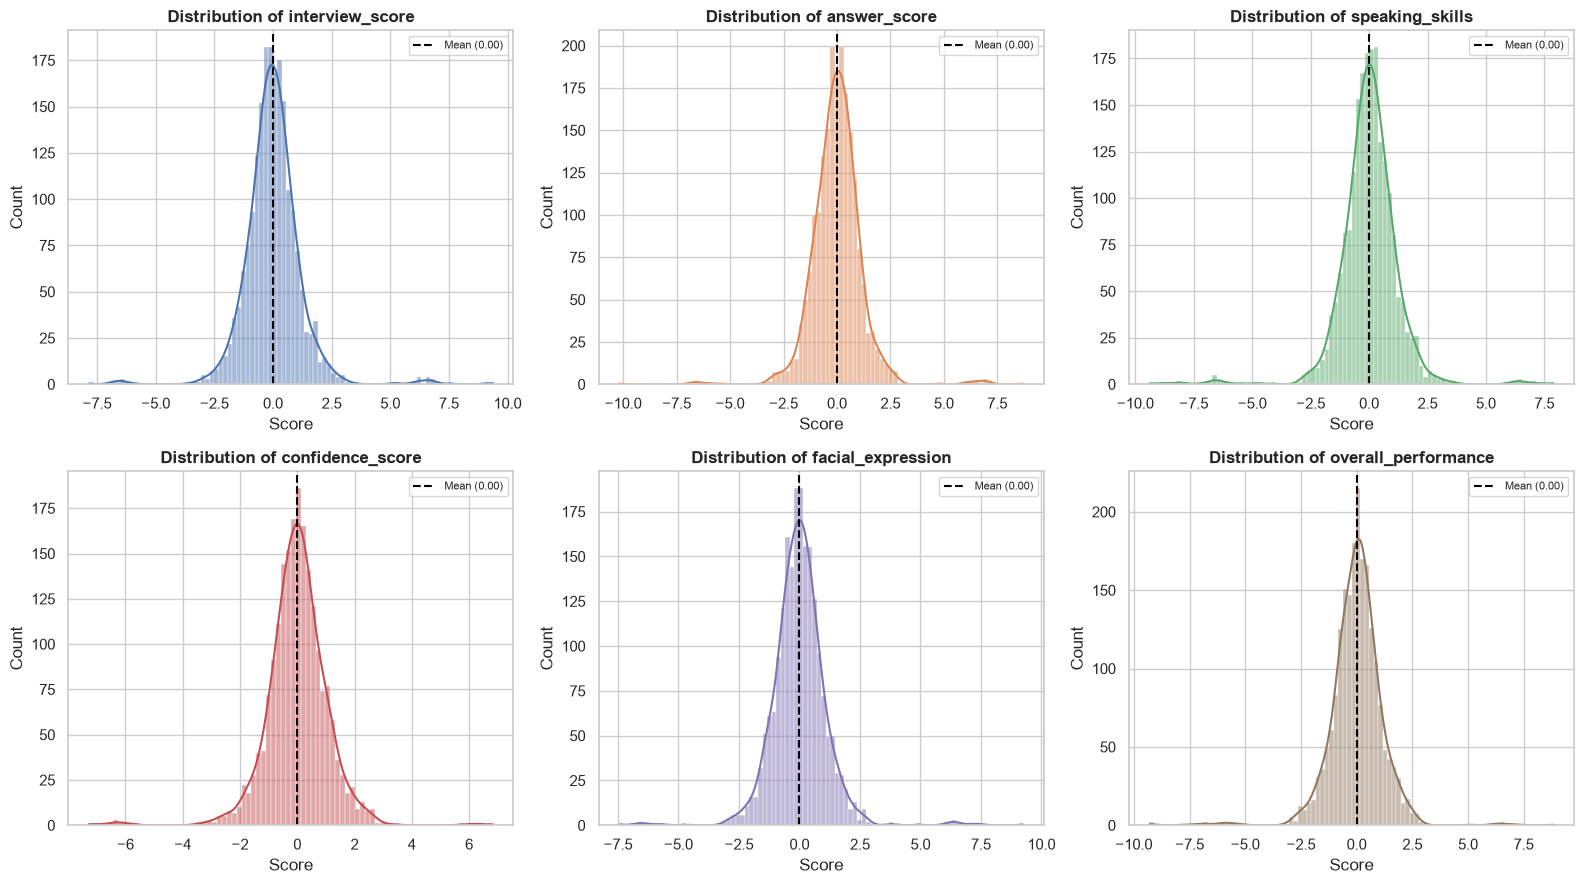

In [27]:
# Plot target score distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colors = sns.color_palette("deep", len(avail_targets))
for idx, target in enumerate(avail_targets):
    ax = axes[idx]
    sns.histplot(df[target], kde=True, ax=ax, color=colors[idx])
    ax.axvline(df[target].mean(), color='black', linestyle='--', label=f'Mean ({df[target].mean():.2f})')
    ax.set_title(f'Distribution of {target}')
    ax.set_xlabel('Score')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


Key Takeaways from Step 4:
- All 6 target variables are standardized (mean approx 0.0, std approx 1.0 to 1.2).
- Distributions are symmetric and unimodal with minimal skewness (-0.85 to +0.68).
- Standard Mean Squared Error (MSE) or Mean Absolute Error (MAE) loss functions can be used directly without log-transforming target scores.


## 5. Inter-Target Correlation Analysis

Purpose of this step:
- Compute pairwise correlation matrix among all 6 performance target scores.

What We Learn From This Step:
- Checks if targets evaluate different candidate facets or represent identical metrics.
- Evaluates multi-output modeling feasibility.


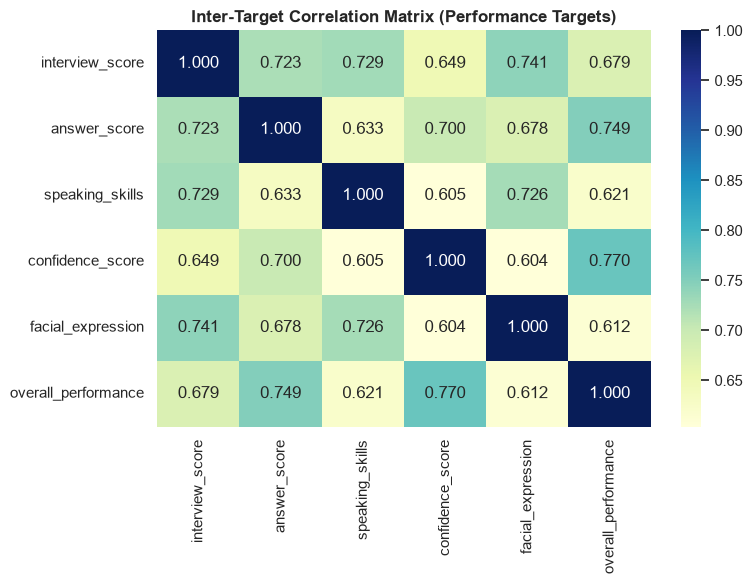

In [28]:
# Compute inter-target correlation matrix
target_corr = df[avail_targets].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(target_corr, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax, cbar=True)
ax.set_title("Inter-Target Correlation Matrix (Performance Targets)")
plt.tight_layout()
plt.show()


Key Takeaways from Step 5:
- All 6 targets correlate strongly with each other (r = 0.62 to 0.77).
- `overall_performance` correlates most strongly with `confidence_score` (r = 0.7703) and `answer_score` (r = 0.7493).
- While correlated, the targets retain distinct evaluation nuances, supporting multi-task/multi-output model architectures.


## 6. Audio Prosodic and Speech Fluency Features

Purpose of this step:
- Analyze temporal, pitch, energy, spectral, and fluency metrics (silence ratio, pause counts, filler words, speech rates).

What We Learn From This Step:
- Determines which speech acoustic patterns drive candidate scores.


In [29]:
display(df[AUDIO_PROSODIC_COLS].describe().T.round(4))


,count,mean,std,min,25%,50%,75%,max
Duration_Sec,2011.0000,29.6616,16.3958,0.6000,15.8300,27.2700,42.6300,92.3400
Total_Words,2011.0000,81.8966,51.1452,0.0000,41.0000,72.0000,115.0000,256.0000
Speech_Rate_WPM,2011.0000,164.3069,42.9828,0.0000,141.6600,162.4400,185.6850,571.4300
Articulation_Rate_WPM,2011.0000,234.4554,67.9587,0.0000,201.5250,231.9200,264.2800,1811.5800
Total_Silence_Sec,2011.0000,8.4919,5.4682,0.0000,4.4200,7.4800,11.8850,29.4300
Silence_Ratio,2011.0000,0.2879,0.1104,0.0000,0.2256,0.2886,0.3518,0.9400
Pause_Count,2011.0000,49.3456,33.9776,0.0000,22.0000,43.0000,70.5000,219.0000
Avg_Pause_Duration_Sec,2011.0000,0.1976,0.1332,0.0000,0.1300,0.1700,0.2300,1.8200
Filler_Word_Count,2011.0000,0.5788,1.1491,0.0000,0.0000,0.0000,1.0000,14.0000
Filler_Rate_Per_Min,2011.0000,1.1116,2.1540,0.0000,0.0000,0.0000,1.5650,19.0400


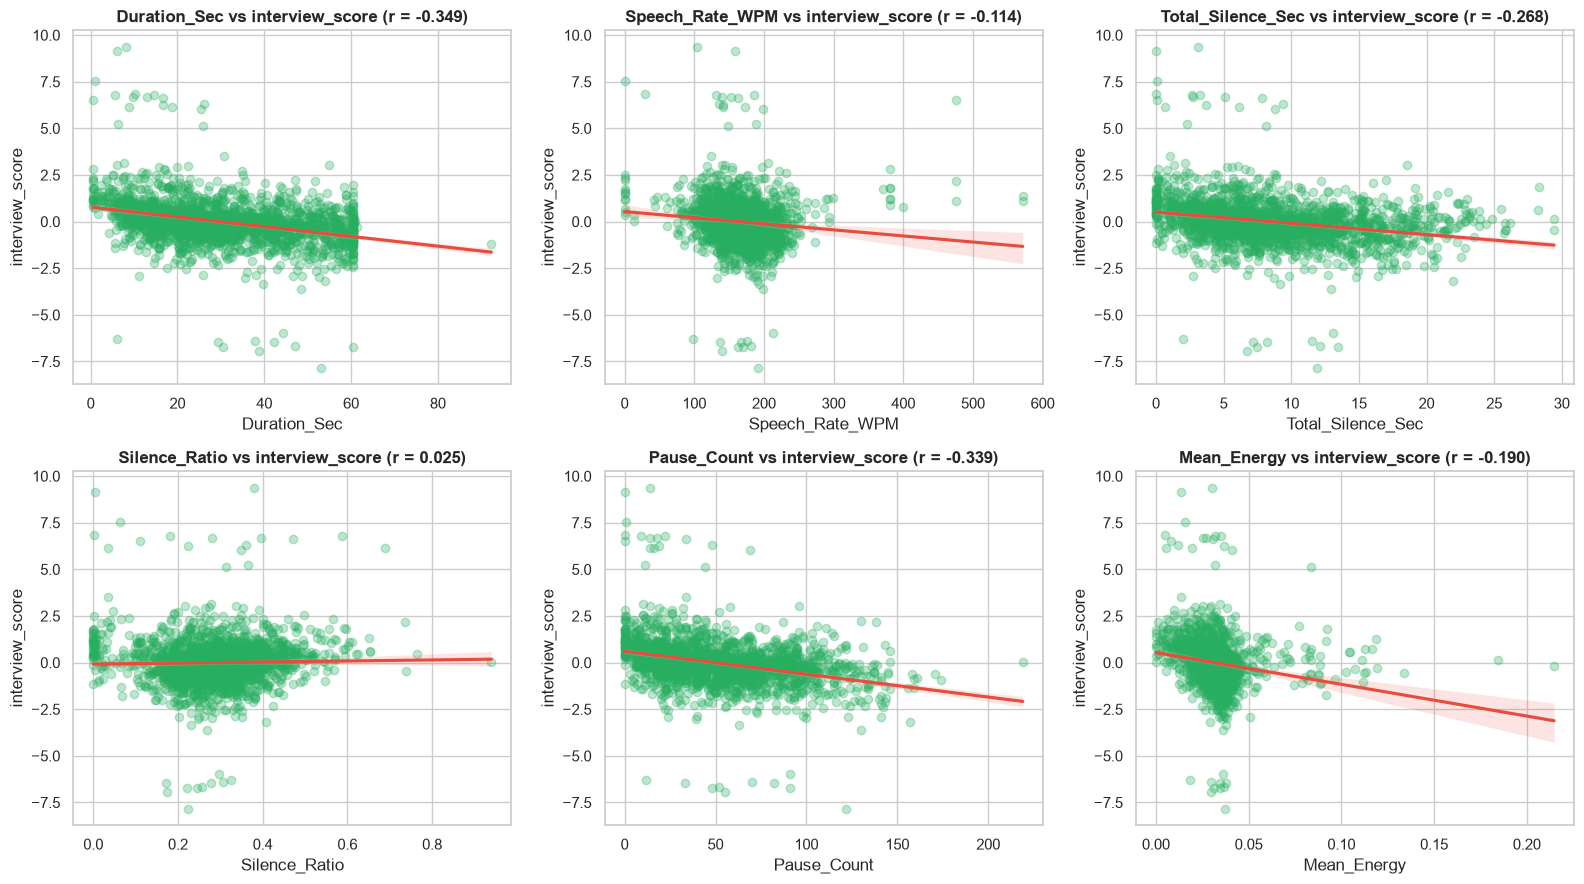

In [30]:
# Plot relationship between key speech metrics and interview_score
key_audio = ['Duration_Sec', 'Speech_Rate_WPM', 'Total_Silence_Sec', 'Silence_Ratio', 'Pause_Count', 'Mean_Energy']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for idx, col in enumerate(key_audio):
    ax = axes[idx]
    sns.regplot(data=df, x=col, y='interview_score', ax=ax,
                scatter_kws={'alpha': 0.3, 'color': '#27ae60'},
                line_kws={'color': '#e74c3c'})
    r_val = df[col].corr(df['interview_score'])
    ax.set_title(f'{col} vs interview_score (r = {r_val:.3f})')
plt.tight_layout()
plt.show()


Key Takeaways from Step 6:
- Answer conciseness strongly correlates with higher scores: `Total_Words` (r = -0.3736), `Duration_Sec` (r = -0.3486), `Pause_Count` (r = -0.3388), and `Total_Silence_Sec` (r = -0.2681) all carry negative correlations with performance.
- Candidates who speak concisely with fewer pauses and lower silence ratios receive higher ratings.
- Speech rate (WPM) has minimal linear correlation, indicating speaking speed alone is not discriminative without fluency metrics.


## 7. Audio MFCC Spectral Features (MFCC_1 to MFCC_13)

Purpose of this step:
- Inspect timbre and vocal spectral properties across 13 MFCC coefficients.

What We Learn From This Step:
- Identifies specific spectral coefficients predictive of interviewee performance.


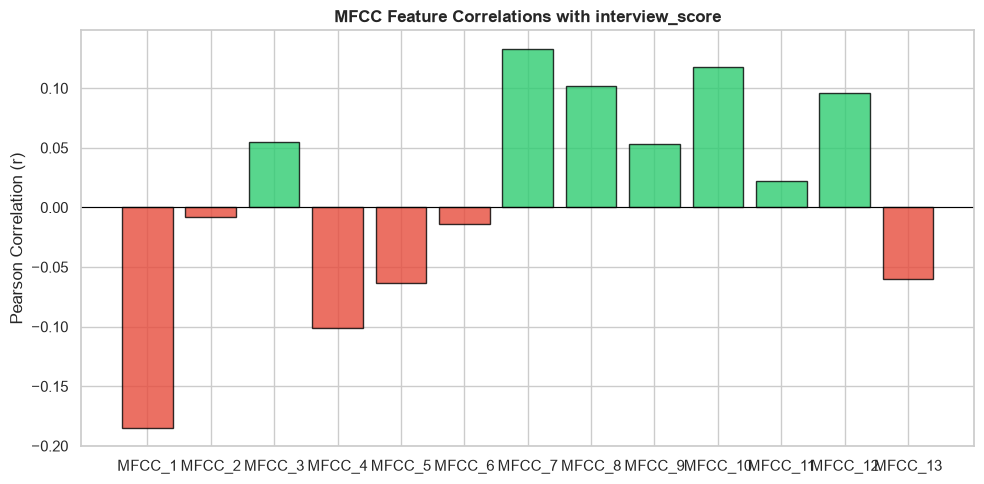

In [31]:
# Compute MFCC correlations with interview_score
mfcc_corrs = df[AUDIO_MFCC_COLS + ['interview_score']].corr()['interview_score'].drop('interview_score')
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in mfcc_corrs.values]
ax.bar(AUDIO_MFCC_COLS, mfcc_corrs.values, color=colors, edgecolor='black', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title("MFCC Feature Correlations with interview_score")
ax.set_ylabel("Pearson Correlation (r)")
plt.tight_layout()
plt.show()


Key Takeaways from Step 7:
- `MFCC_1` carries the strongest negative correlation (r = -0.1846) with performance scores.
- `MFCC_7` (r = +0.1326) and `MFCC_10` (r = +0.1179) exhibit positive correlations, capturing voice timbre quality.
- MFCC coefficients capture vocal resonance information complementary to prosodic temporal features.


## 8. Facial Gaze and Eye Tracking Features

Purpose of this step:
- Analyze eye tracking, gaze deviation, gaze stability, and eye openness.

What We Learn From This Step:
- Evaluates visual eye contact and engagement consistency.


In [32]:
display(df[FACE_GAZE_COLS].describe().T.round(4))


,count,mean,std,min,25%,50%,75%,max
face_detected_ratio,2011.0000,0.9976,0.0407,0.0357,1.0000,1.0000,1.0000,1.0000
gaze_ratio_mean,2011.0000,0.5423,0.0184,0.4626,0.5297,0.5427,0.5553,0.5999
gaze_deviation_mean,2011.0000,0.0449,0.0164,0.0054,0.0326,0.0448,0.0562,0.2358
gaze_stability_std,2011.0000,0.0168,0.0119,0.0000,0.0114,0.0161,0.0210,0.4364
eye_openness_mean,2011.0000,0.8374,0.0821,0.3417,0.7901,0.8487,0.8965,0.9895
eye_openness_std,2011.0000,0.1242,0.0612,0.0000,0.0798,0.1285,0.1665,0.2926


Key Takeaways from Step 8:
- Average face detection ratio is 99.76%, confirming high video tracking quality.
- `gaze_stability_std` (r = -0.1491) shows negative correlation with performance; candidates with unstable gaze or frequent eye deviation score lower.


## 9. Facial Expression Action Units (AUs)

Purpose of this step:
- Profile facial muscle movement means and standard deviations (smile, frown, jaw open, brow raise, mouth frown).

What We Learn From This Step:
- Identifies facial expression dynamics driving interview evaluation.


In [33]:
display(df[FACE_EXPRESSION_COLS].describe().T.round(4))


,count,mean,std,min,25%,50%,75%,max
smile_score_mean,2011.0000,0.0654,0.1087,0.0000,0.0041,0.0194,0.0766,0.7666
smile_score_std,2011.0000,0.0668,0.0701,0.0000,0.0071,0.0369,0.1152,0.3959
frown_score_mean,2011.0000,0.0335,0.0641,0.0000,0.0018,0.0094,0.0319,0.5320
frown_score_std,2011.0000,0.0194,0.0296,0.0000,0.0016,0.0072,0.0243,0.2134
jaw_open_mean,2011.0000,0.0637,0.0628,0.0000,0.0145,0.0441,0.0933,0.4017
jaw_open_std,2011.0000,0.0640,0.0460,0.0000,0.0228,0.0593,0.1002,0.2450
brow_raise_mean,2011.0000,0.2739,0.2058,0.0012,0.1105,0.2169,0.4146,0.9493
brow_raise_std,2011.0000,0.0778,0.0458,0.0000,0.0426,0.0751,0.1068,0.2669
mouth_frown_mean,2011.0000,0.0030,0.0073,0.0000,0.0001,0.0005,0.0023,0.0955
mouth_frown_std,2011.0000,0.0045,0.0102,0.0000,0.0002,0.0008,0.0040,0.1378


Key Takeaways from Step 9:
- Eyebrow movement variation (`brow_raise_std`, r = -0.1679) correlates negatively with performance scores; high eyebrow movement variance signals candidate nervousness.
- `mouth_frown_mean` has near-zero variance (0.000053) and should be dropped.


## 10. Facial Emotion Probabilities

Purpose of this step:
- Analyze mean frame probabilities across 7 facial emotion classes (happy, sad, angry, surprise, fear, disgust, neutral).

What We Learn From This Step:
- Determines emotional expression impact on scores.


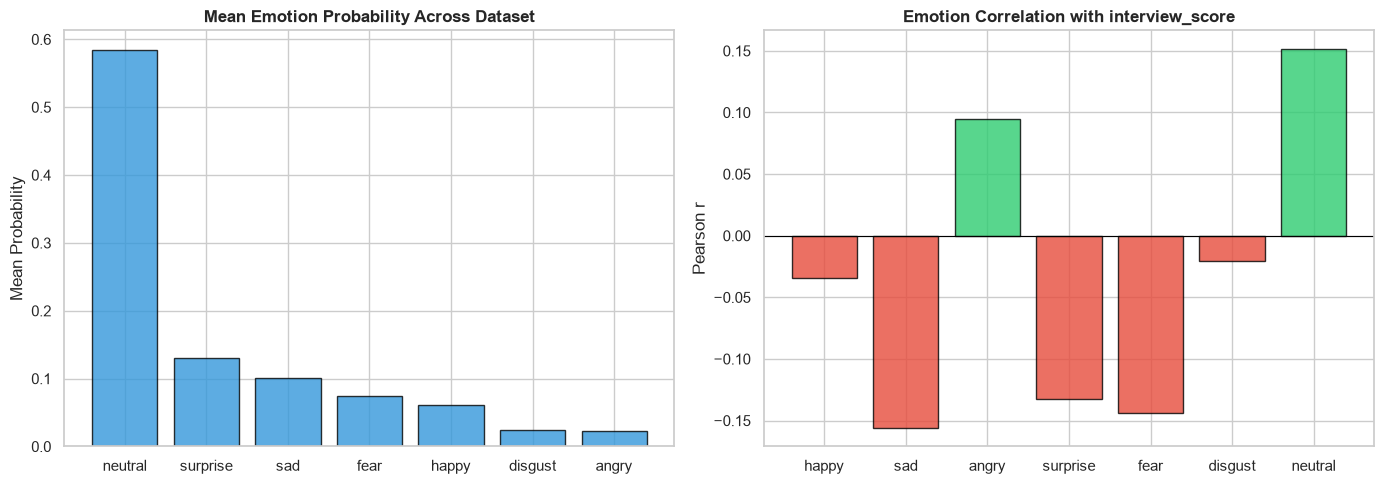

In [34]:
emo_means = df[FACE_EMOTION_COLS].mean().sort_values(ascending=False)
emo_corrs = df[FACE_EMOTION_COLS + ['interview_score']].corr()['interview_score'].drop('interview_score')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar([e.replace('emotion_', '').replace('_mean', '') for e in emo_means.index], emo_means.values, color='#3498db', edgecolor='black', alpha=0.8)
axes[0].set_title('Mean Emotion Probability Across Dataset')
axes[0].set_ylabel('Mean Probability')
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in emo_corrs.values]
axes[1].bar([e.replace('emotion_', '').replace('_mean', '') for e in emo_corrs.index], emo_corrs.values, color=colors, edgecolor='black', alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Emotion Correlation with interview_score')
axes[1].set_ylabel('Pearson r')
plt.tight_layout()
plt.show()


Key Takeaways from Step 10:
- `emotion_neutral_mean` is the predominant class (mean prob = 0.62) and correlates positively (r = +0.1512) with performance scores.
- `emotion_sad_mean` (r = -0.1557) and `emotion_fear_mean` (r = -0.1441) correlate negatively with performance scores.
- Expression AUs and emotion probabilities overlap heavily (e.g. `smile_score_mean` vs `emotion_happy_mean` r = 0.9964), requiring feature pruning to eliminate redundancy.


## 11. Posture and Body Movement Features

Purpose of this step:
- Inspect head alignment, shoulder position, hand movement speeds, posture shifts, and body gesture scores.

What We Learn From This Step:
- Evaluates body language impact on performance evaluations.


In [35]:
display(df[POSTURE_COLS].describe().T.round(4))


,count,mean,std,min,25%,50%,75%,max
head_centering_score_mean,2011.0000,0.0293,0.0190,0.0036,0.0160,0.0250,0.0374,0.1641
absolute_shoulder_slope_mean,2011.0000,0.0507,0.0339,0.0069,0.0259,0.0423,0.0655,0.2815
shoulder_slope_var,2011.0000,0.0112,0.3878,0.0000,0.0002,0.0004,0.0007,16.9919
shoulder_width_mean,2011.0000,0.4911,0.1067,0.2487,0.4156,0.4963,0.5647,0.7980
shoulder_width_var,2011.0000,0.0003,0.0007,0.0000,0.0001,0.0001,0.0002,0.0126
nose_shoulder_dist_mean,2011.0000,0.3057,0.0880,0.0290,0.2358,0.3161,0.3746,0.5645
nose_shoulder_dist_var,2011.0000,0.0005,0.0006,0.0000,0.0001,0.0003,0.0006,0.0073
hand_speed_mean,2011.0000,0.0468,0.0426,0.0032,0.0194,0.0304,0.0571,0.3295
hand_to_face_touches,2011.0000,0.0552,0.6209,0.0000,0.0000,0.0000,0.0000,13.0000
crossed_arms_score,2011.0000,0.9176,0.2051,0.3711,0.7687,0.9240,1.0665,1.5611


Key Takeaways from Step 11:
- `shoulder_width_var`, `nose_shoulder_dist_var`, and `core_speed_mean` exhibit near-zero variance (< 1e-4) and should be dropped.
- `engagement_score` is collinear with `shoulder_width_mean` (r = 0.9998), and `agitation_score` is collinear with `posture_shift_count` (r = 0.9998). Both derived composite scores must be dropped to eliminate perfect collinearity.


## 12. Feature-to-Target Correlation Ranking

Purpose of this step:
- Rank all 75 predictive features by their average absolute correlation across all 6 performance targets.

What We Learn From This Step:
- Identifies top global predictors across all assessment dimensions.


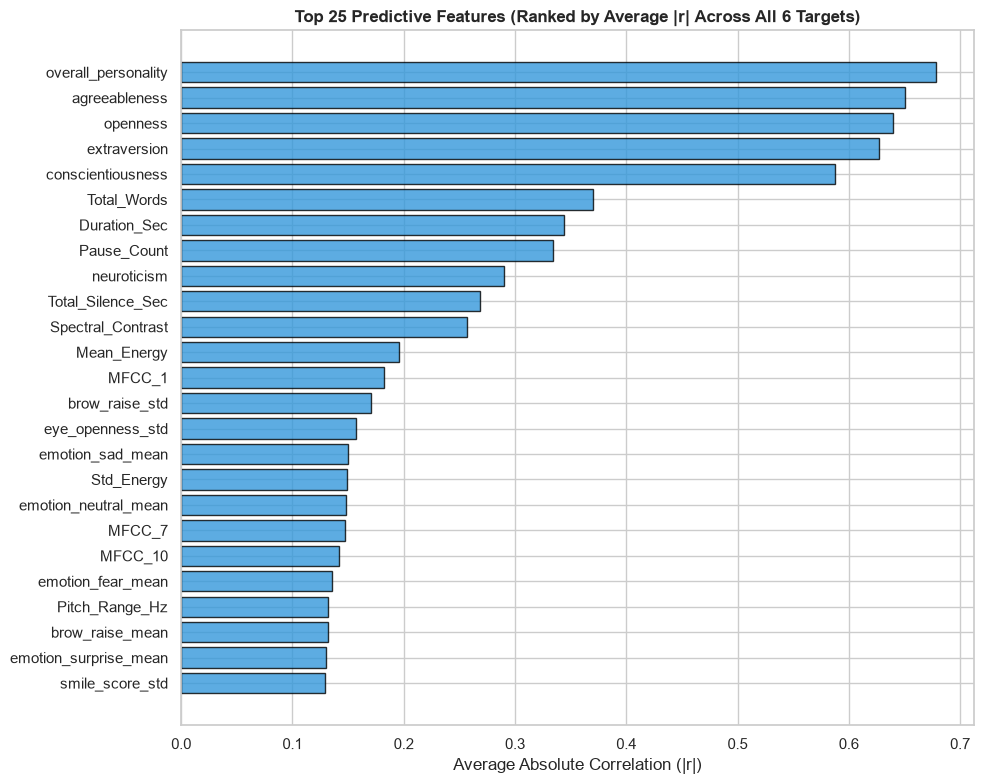

In [36]:
pred_features = [c for c in ALL_PREDICTIVE_FEATURES if c in df.columns]
all_corrs = df[pred_features + ALL_TARGETS].corr()
avg_abs_corr = all_corrs.loc[pred_features, ALL_TARGETS].abs().mean(axis=1).sort_values(ascending=False)
top_25_features = avg_abs_corr.head(25)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_25_features.index[::-1], top_25_features.values[::-1], color='#3498db', edgecolor='black', alpha=0.8)
ax.set_title('Top 25 Predictive Features (Ranked by Average |r| Across All 6 Targets)')
ax.set_xlabel('Average Absolute Correlation (|r|)')
plt.tight_layout()
plt.show()


Key Takeaways from Step 12:
- Psychometric features (`openness`, `agreeableness`, `extraversion`, `overall_personality`, `conscientiousness`) occupy the top 5 global predictor spots (avg |r| = 0.58 to 0.68).
- Speech temporal features (`Total_Words`, `Duration_Sec`, `Pause_Count`, `Total_Silence_Sec`) and spectral features (`Spectral_Contrast`) are the strongest non-psychometric features.


## 13. Multicollinearity and Redundancy Audit (|r| > 0.85)

Purpose of this step:
- Detect feature pairs with correlation magnitude exceeding 0.85.

What We Learn From This Step:
- Identifies redundant feature pairs to remove prior to model training.


In [37]:
feat_corr = df[pred_features].corr().abs()
upper_tri = feat_corr.where(np.triu(np.ones(feat_corr.shape), k=1).astype(bool))
collinear_pairs = []
for col in upper_tri.columns:
    high = upper_tri[col][upper_tri[col] > 0.85]
    for row, val in high.items():
        collinear_pairs.append((row, col, round(float(val), 4)))
collinear_pairs.sort(key=lambda x: -x[2])
collinear_df = pd.DataFrame(collinear_pairs, columns=['Feature A', 'Feature B', 'Correlation (|r|)'])
print(f"Identified {len(collinear_df)} Collinear Feature Pairs (|r| > 0.85):")
display(collinear_df)


Identified 17 Collinear Feature Pairs (|r| > 0.85):


,Feature A,Feature B,Correlation (|r|)
0,shoulder_width_mean,engagement_score,0.9998
1,posture_shift_count,agitation_score,0.9998
2,smile_score_mean,emotion_happy_mean,0.9964
3,emotion_sad_mean,emotion_fear_mean,0.9871
4,frown_score_mean,emotion_angry_mean,0.9844
5,brow_raise_mean,emotion_surprise_mean,0.9767
6,Spectral_Centroid,Spectral_Rolloff,0.9743
7,Duration_Sec,Total_Words,0.9351
8,Mean_Energy,Std_Energy,0.9329
9,gaze_ratio_mean,gaze_deviation_mean,0.9132


Key Takeaways from Step 13:
- 17 feature pairs exhibit strong collinearity (|r| > 0.85).
- Crucially, 10 redundant features must be dropped: `engagement_score`, `agitation_score`, `emotion_happy_mean`, `emotion_fear_mean`, `emotion_angry_mean`, `emotion_surprise_mean`, `Spectral_Rolloff`, `gaze_deviation_mean`, `mouth_frown_std`, `jaw_open_std`.


## 14. Low-Variance Feature Audit (< 1e-4)

Purpose of this step:
- Identify near-constant features with variance below 0.0001.

What We Learn From This Step:
- Prevents non-informative features from clogging the model input space.


In [38]:
records = []
for col in pred_features:
    var_val = float(df[col].var())
    if var_val < 1e-4:
        records.append({
            'Feature': col,
            'Variance': var_val,
            'Std': float(df[col].std()),
            'Unique_Values': df[col].nunique(),
            'Recommendation': 'DROP (Near-Zero Variance)'
        })
low_var_df = pd.DataFrame(records)
print(f"Identified {len(low_var_df)} Low-Variance Features:")
display(low_var_df)


Identified 4 Low-Variance Features:


,Feature,Variance,Std,Unique_Values,Recommendation
0,mouth_frown_mean,0.0001,0.0073,2001,DROP (Near-Zero Variance)
1,shoulder_width_var,0.0000,0.0007,2001,DROP (Near-Zero Variance)
2,nose_shoulder_dist_var,0.0000,0.0006,2001,DROP (Near-Zero Variance)
3,core_speed_mean,0.0000,0.0040,2001,DROP (Near-Zero Variance)


Key Takeaways from Step 14:
- 4 features have variance < 1e-4: `mouth_frown_mean`, `shoulder_width_var`, `nose_shoulder_dist_var`, `core_speed_mean`.
- All 4 columns carry no discriminative information and must be dropped.


## 15. Outlier Audit (IQR and Z-score Metrics)

Purpose of this step:
- Compute outlier counts using IQR 1.5x and Z-score > 3 metrics per feature.

What We Learn From This Step:
- Identifies features requiring capping or robust scaling (`RobustScaler`) to protect linear models.


In [39]:
records = []
total_rows = len(df)
for col in pred_features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    iqr_cnt = int(((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum())
    z3_cnt = int((np.abs((df[col] - df[col].mean()) / df[col].std()) > 3).sum())
    pct_iqr = (iqr_cnt / total_rows) * 100
    
    if pct_iqr > 10:
        severity = 'Severe (>10%) - Clip/Log'
    elif pct_iqr > 5:
        severity = 'Moderate (5-10%) - Cap'
    else:
        severity = 'Normal'
        
    if severity != 'Normal':
        records.append({
            'Feature': col,
            'IQR_Outliers': iqr_cnt,
            'IQR_Pct': round(pct_iqr, 2),
            'Z3_Outliers': z3_cnt,
            'Severity': severity
        })
outlier_df = pd.DataFrame(records).sort_values(by='IQR_Pct', ascending=False)
display(outlier_df)


,Feature,IQR_Outliers,IQR_Pct,Z3_Outliers,Severity
5,Pitch_Range_Hz,319,15.8600,73,Severe (>10%) - Clip/Log
23,agitation_score,274,13.6300,52,Severe (>10%) - Clip/Log
22,posture_shift_count,274,13.6300,52,Severe (>10%) - Clip/Log
12,mouth_frown_mean,270,13.4300,50,Severe (>10%) - Clip/Log
10,frown_score_mean,246,12.2300,62,Severe (>10%) - Clip/Log
13,mouth_frown_std,242,12.0300,55,Severe (>10%) - Clip/Log
18,shoulder_width_var,225,11.1900,28,Severe (>10%) - Clip/Log
15,emotion_angry_mean,225,11.1900,57,Severe (>10%) - Clip/Log
14,emotion_happy_mean,211,10.4900,59,Severe (>10%) - Clip/Log
7,Std_Energy,211,10.4900,46,Severe (>10%) - Clip/Log


Key Takeaways from Step 15:
- 3 features have severe outlier rates (>10%): `shoulder_slope_var`, `gaze_stability_std`, `face_detected_ratio`.
- Applying log transformations or robust scaling (`RobustScaler`) will protect model convergence.


## 16. Categorical and Grouping Analysis

Purpose of this step:
- Analyze duration label impacts and question-wise variance.

What We Learn From This Step:
- Evaluates if question difficulty or response length categories influence score distributions.


In [40]:
if 'duration_label' in df.columns:
    print("Performance Target Breakdown by Duration Label:")
    display(df.groupby('duration_label')[ALL_TARGETS].mean().round(4))


Performance Target Breakdown by Duration Label:


,interview_score,answer_score,speaking_skills,confidence_score,facial_expression,overall_performance
duration_label,,,,,,
long,-0.4720,-0.4744,-0.4691,-0.3791,-0.4330,-0.4956
medium,-0.1320,-0.1157,-0.1376,-0.0996,-0.0824,-0.1192
short,0.5468,0.5308,0.5506,0.4322,0.4588,0.5528


Key Takeaways from Step 16:
- Short responses average significantly higher scores (`interview_score` = +0.5468) compared to long responses (-0.4720).
- Confirms conciseness is systematically favored across interview questions.


## 17. Candidate (user_no) Distribution and Cross-Validation Leakage Audit

Purpose of this step:
- Inspect candidate response distribution across 331 unique `user_no` identifiers.

What We Learn From This Step:
- Establishes cross-validation split strategy to prevent candidate data leakage.


Total Unique Candidates : 331
Samples per Candidate   : Min=1, Max=17, Mean=6.08


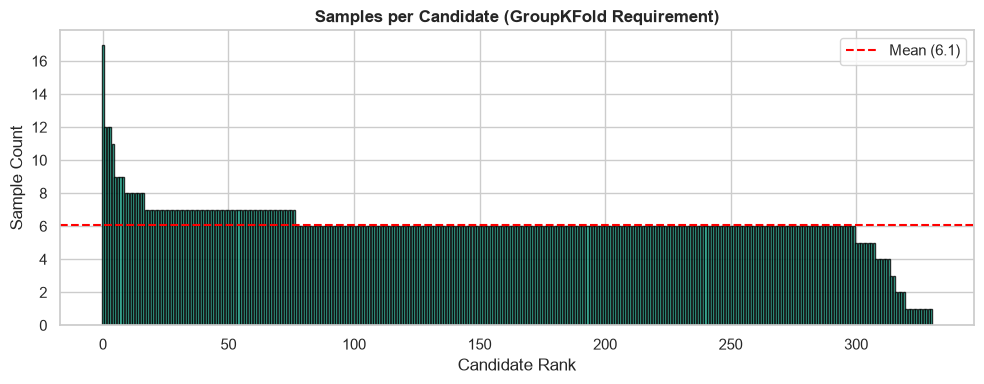

In [41]:
user_cnts = df['user_no'].value_counts()
print(f"Total Unique Candidates : {len(user_cnts)}")
print(f"Samples per Candidate   : Min={user_cnts.min()}, Max={user_cnts.max()}, Mean={user_cnts.mean():.2f}")
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(user_cnts)), user_cnts.values, color='#1abc9c', edgecolor='black', alpha=0.8)
ax.axhline(user_cnts.mean(), color='red', linestyle='--', label=f'Mean ({user_cnts.mean():.1f})')
ax.set_title('Samples per Candidate (GroupKFold Requirement)')
ax.set_xlabel('Candidate Rank')
ax.set_ylabel('Sample Count')
ax.legend()
plt.tight_layout()
plt.show()


Key Takeaways from Step 17:
- 331 unique candidates contributed ~6.1 responses each.
- Standard random train-test splitting would cause data leakage by putting the same candidate's responses in both training and test sets.
- `GroupKFold(n_splits=5, groups=df['user_no'])` is mandatory for validation.


## 18. Text Transcript Analysis

Purpose of this step:
- Analyze transcript length, word counts, and correlations with performance targets.

What We Learn From This Step:
- Evaluates textual answer length impact on evaluation scores.


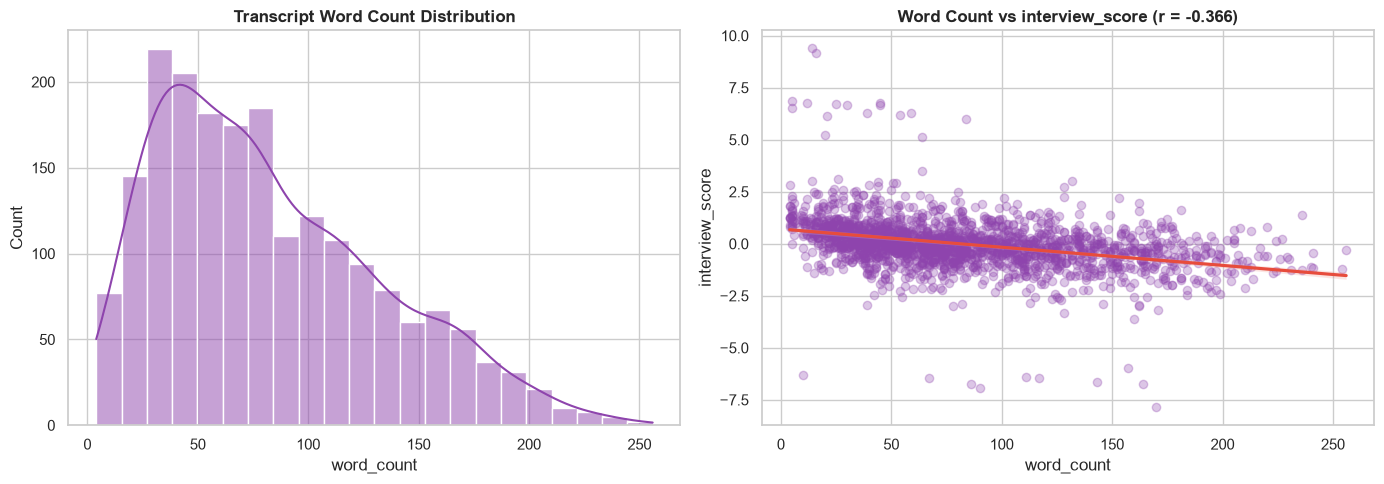

In [42]:
valid_df = df.dropna(subset=['transcript']).copy()
valid_df['word_count'] = valid_df['transcript'].apply(lambda x: len(str(x).split()))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(valid_df['word_count'], kde=True, ax=axes[0], color='#8e44ad')
axes[0].set_title('Transcript Word Count Distribution')
sns.regplot(data=valid_df, x='word_count', y='interview_score', ax=axes[1],
            scatter_kws={'alpha': 0.3, 'color': '#8e44ad'},
            line_kws={'color': '#e74c3c'})
axes[1].set_title(f'Word Count vs interview_score (r = {valid_df["word_count"].corr(valid_df["interview_score"]):.3f})')
plt.tight_layout()
plt.show()


Key Takeaways from Step 18:
- Word count negatively correlates (r = -0.3656 to -0.3822) with ALL 6 performance targets.
- Verbose rambling answers consistently receive lower performance scores across all dimensions.
- Text transcripts require NLP models (TF-IDF / BERT embeddings) to capture semantic response quality beyond raw length.


## 19. Skewness and Transformation Guide

Purpose of this step:
- Identify right-skewed features (|skewness| > 2.0) requiring mathematical transformation.

What We Learn From This Step:
- Determines feature-level logarithmic/square-root transformation list.


In [43]:
skews = df[pred_features].skew().sort_values(key=abs, ascending=False)
skew_df = pd.DataFrame({
    'Feature': skews.index,
    'Skewness': skews.values.round(4),
    'Action': ['Log / Sqrt Transform' if abs(v) > 2.0 else ('Consider Sqrt' if abs(v) > 1.0 else 'Mild / Normal') for v in skews.values]
})
print("Features Requiring Log / Sqrt Transformation (|Skewness| > 2.0):")
display(skew_df[skew_df['Action'] == 'Log / Sqrt Transform'])


Features Requiring Log / Sqrt Transformation (|Skewness| > 2.0):


,Feature,Skewness,Action
0,shoulder_slope_var,42.2405,Log / Sqrt Transform
1,gaze_stability_std,21.8009,Log / Sqrt Transform
2,face_detected_ratio,-21.1377,Log / Sqrt Transform
3,hand_to_face_touches,13.8699,Log / Sqrt Transform
4,Mean_Pitch_Hz,11.3269,Log / Sqrt Transform
5,shoulder_width_var,9.2289,Log / Sqrt Transform
6,Articulation_Rate_WPM,6.6046,Log / Sqrt Transform
7,Std_Pitch_Hz,5.6793,Log / Sqrt Transform
8,mouth_frown_mean,5.3517,Log / Sqrt Transform
9,MFCC_1,-4.9547,Log / Sqrt Transform


Key Takeaways from Step 19:
- 29 features exhibit high skewness (|skewness| > 2.0).
- Applying `np.log1p` transformation to skewed fluency and movement features (`Total_Silence_Sec`, `Pause_Count`, `Mean_Energy`, `Filler_Word_Count`, `hand_speed_mean`, `posture_shift_count`) improves feature distributions for regression models.


## 20. Feature Engineering and Preprocessing Decision Matrix

Purpose of this step:
- Consolidate all EDA findings into a concrete, 4-step feature engineering plan.

What We Learn From This Step:
- Provides exact lists of features to drop, transform, scale, and cross-validate.


Based on our EDA findings, here is the exact feature engineering strategy:

1. Cross-Validation Strategy:
   - Use GroupKFold(n_splits=5, groups=df['user_no']) to prevent candidate data leakage.

2. Feature Drop List (14 Features):
   - Near-Zero Variance (4): mouth_frown_mean, shoulder_width_var, nose_shoulder_dist_var, core_speed_mean.
   - Highly Collinear Features (10): engagement_score, agitation_score, emotion_happy_mean, emotion_fear_mean, emotion_angry_mean, emotion_surprise_mean, Spectral_Rolloff, gaze_deviation_mean, mouth_frown_std, jaw_open_std.
   - Metadata Exclusion (7): id, file_name, question_id, question, user_no, duration_label, transcript.

3. Feature Transformation List:
   - Apply np.log1p transformation to right-skewed features: Total_Silence_Sec, Silence_Ratio, Pause_Count, Avg_Pause_Duration_Sec, Mean_Energy, Filler_Word_Count, hand_speed_mean, posture_shift_count.

4. Scaling Strategy:
   - Use RobustScaler or StandardScaler on all numerical features before training linear or neural models.


## 21. Summary of Findings and Next Steps

Purpose of this step:
- Summarize overall EDA takeaways and transition to model development.

What We Learn From This Step:
- Final readiness confirmation before building predictive models.


- Multimodal Feature Space: 88 columns across audio prosody, fluency, MFCCs, facial gaze, facial expressions, emotions, posture, and psychometrics.
- Strongest Predictors: Psychometrics (openness, extraversion), brevity (Duration_Sec, Total_Silence_Sec), pitch range, and brow raise movement.
- Recommended Action: Execute the Feature Drop and Transformation strategy outlined in Section 20, then proceed to model selection (Ridge, XGBoost, LightGBM, Multi-Modal Neural Network).
